In [38]:
# --- Setup: add project root to sys.path so that src is discoverable ---
import sys
from pathlib import Path
project_root = Path.cwd().parent  # assuming current working directory is 'notebook'
sys.path.insert(0, str(project_root))

# --- Imports from our modules ---
from src.config.loaders import load_config, load_station_data
from src.data.engineering import engineer_data
from src.data.scaling import scale_df, inverse_scale
from src.data.windowing import data_to_X_y
from src.visualization.plotting import plot_loss, plot_predictions

from src.models.lstm import build_simple_lstm_model, build_optimized_lstm_model, build_residual_lstm_model
from src.models.cnn import build_cnn_model

# --- Standard Setup ---
import matplotlib.pyplot as plt
import os
import tensorflow as tf
import numpy as np
import pandas as pd

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = False
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [17]:
# --- Load configuration ---
cfg = load_config()

model_builders = {
    "Simple LSTM": build_simple_lstm_model,
    "Optimized LSTM": build_optimized_lstm_model,
    "CNN": build_cnn_model
}

In [18]:
# --- Load and preprocess data ---
station_data = load_station_data(cfg)
for station in station_data:
    print(f"Engineering features for {station} ...")
    station_data[station] = engineer_data(station_data[station])

# For forecasting, choose Station1 (for example)
df_forecast = station_data["Station1"]
scaled_df, scaler = scale_df(df_forecast)

Loaded data from 6 stations: ['Station4', 'Station3', 'Station6', 'Station1', 'Station2', 'Station5']
Engineering features for Station4 ...
Engineering features for Station3 ...
Engineering features for Station6 ...
Engineering features for Station1 ...
Engineering features for Station2 ...
Engineering features for Station5 ...


In [19]:
# --- Create Sliding Windows ---
TARGET_COLUMN = cfg["model"]["target_column"]  # "SWC_20"
WINDOW_SIZE = cfg["model"]["window_size"]         # 72
OFFSET = cfg["model"].get("offset", 24)             # 24
X, y = data_to_X_y(scaled_df[TARGET_COLUMN], WINDOW_SIZE, OFFSET)
print("Full sliding windows shapes: X =", X.shape, ", y =", y.shape)

Full sliding windows shapes: X = (52464, 72, 1) , y = (52464,)


In [20]:
# Split into training (70%), validation (20%), test (10%)
n = len(X)
X_train, y_train = X[:int(n*0.7)], y[:int(n*0.7)]
X_val, y_val = X[int(n*0.7):int(n*0.9)], y[int(n*0.7):int(n*0.9)]
X_test, y_test = X[int(n*0.9):], y[int(n*0.9):]
print("Split shapes -- X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)


Split shapes -- X_train: (36724, 72, 1) X_val: (10493, 72, 1) X_test: (5247, 72, 1)


In [21]:
# --- Build and Train Model ---
model = build_simple_lstm_model(WINDOW_SIZE, 1)
checkpoint_path = "model1.keras"
cp = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_loss', mode='min')
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, mode='min')
EPOCHS = cfg["lstm"]["epochs"]
BATCH_SIZE = cfg["lstm"]["batch_size"]
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    callbacks=[cp, early_stopping])

# TODO: Fix size of either model or yintput train

Epoch 1/10


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


1148/1148 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0788 - root_mean_squared_error: 0.2596 - val_loss: 0.0038 - val_root_mean_squared_error: 0.0618
Epoch 2/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0048 - root_mean_squared_error: 0.0692 - val_loss: 0.0036 - val_root_mean_squared_error: 0.0599
Epoch 3/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0046 - root_mean_squared_error: 0.0674 - val_loss: 0.0034 - val_root_mean_squared_error: 0.0582
Epoch 4/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0042 - root_mean_squared_error: 0.0651 - val_loss: 0.0033 - val_root_mean_squared_error: 0.0576
Epoch 5/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0041 - root_mean_squared_error: 0.0640 - val_loss: 0.0032 - val_root_mean_squared_error: 0.0570
Epoch 6/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0036 - root_mean_squared_error: 0.0602 - val_loss: 0.0031 - val_root_mean_squared_error: 0.0558
Epoch 7/10
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/st

In [44]:
y_train2 = y_train.reshape(-1, 1)
y_train2.shape

X_train.shape

model2 = build_residual_lstm_model(WINDOW_SIZE, 1)
model2.summary()  # Check model output shape


Model: "residual_wrapper_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_23 (Sequential)      │ (None, 1)              │         4,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model2 = build_residual_lstm_model(WINDOW_SIZE, 1)
# model2.summary()
checkpoint_path2 = "model2.keras"
cp2 = tf.keras.callbacks.ModelCheckpoint(checkpoint_path2, save_best_only=True, monitor='val_loss', mode='min')
early_stopping2 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, mode='min')
history2 = model2.fit(X_train, y_train2,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS, batch_size=BATCH_SIZE,
                    callbacks=[cp2, early_stopping2])

Epoch 1/10


InvalidArgumentError: Graph execution error:

Detected at node gradient_tape/residual_wrapper_23_1/add/BroadcastGradientArgs defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/Users/ethanchandra/Library/Python/3.12/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/Users/ethanchandra/Library/Python/3.12/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/Users/ethanchandra/Library/Python/3.12/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.py", line 641, in run_forever

  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/asyncio/base_events.

In [7]:
# --- Reload Best Model and Generate Predictions ---
model = tf.keras.models.load_model(checkpoint_path)
predictions_scaled = model.predict(X_test).flatten()

# Load Residual model
model2 = tf.keras.models.load_model(checkpoint_path2)
predictions_scaled2 = model2.predict(X_test).flatten()

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [8]:
preds_inv_df = inverse_scale(predictions_scaled, scaled_df, TARGET_COLUMN)
predictions_rescaled = preds_inv_df[TARGET_COLUMN].values

actual_inv_df = inverse_scale(y_test.reshape(-1, 1), scaled_df, TARGET_COLUMN)
y_actual = actual_inv_df[TARGET_COLUMN].values
print("First 5 rescaled predictions:", predictions_rescaled[:5])

preds_inv_df2 = inverse_scale(predictions_scaled2, scaled_df, TARGET_COLUMN)
predictions_rescaled2 = preds_inv_df2[TARGET_COLUMN].values

actual_inv_df2 = inverse_scale(y_test.reshape(-1, 1), scaled_df, TARGET_COLUMN)
y_actual2 = actual_inv_df2[TARGET_COLUMN].values
print("Residual: First 5 rescaled predictions:", predictions_rescaled2[:5])

First 5 rescaled predictions: [0.79970348 0.80428028 0.80617827 0.80693495 0.80571043]


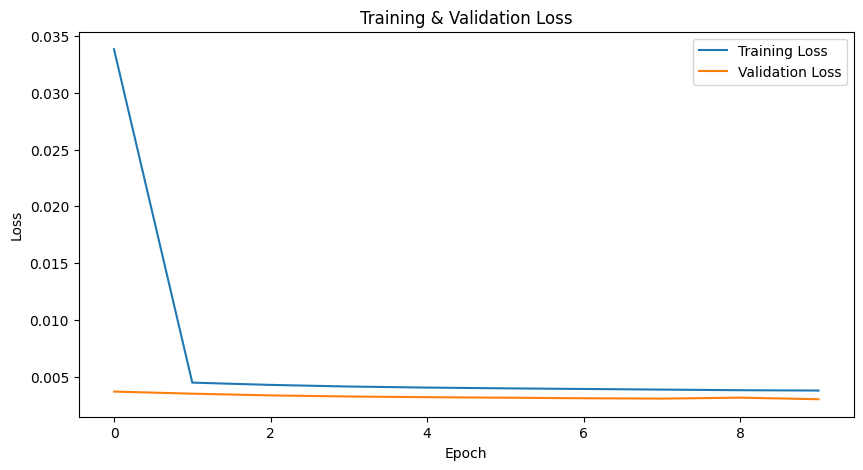

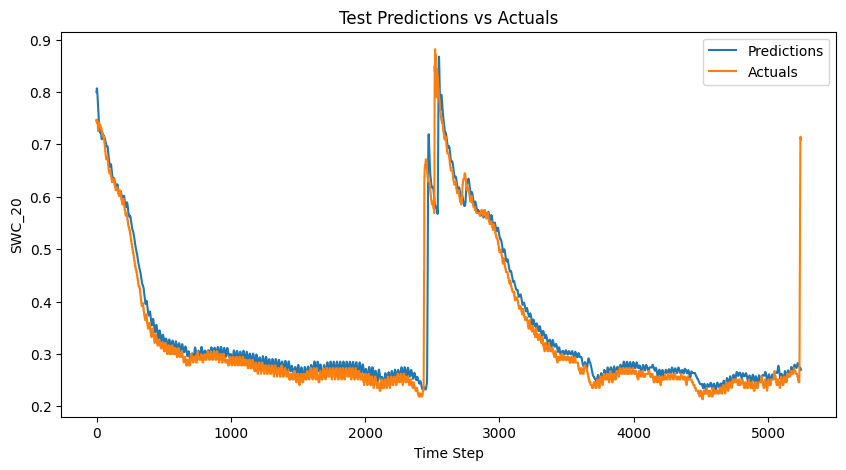

R2 Score: 0.9082895401186352
Mean Squared Error: 0.0017733176532125142
Mean Absolute Error: 0.01884229218239303
Mean Absolute Percentage Error: 0.053789099367574526


In [9]:
# --- Plot Loss and Predictions ---
plot_loss(history)
plot_predictions(y_actual, predictions_rescaled, TARGET_COLUMN)

# --- Print Evaluation Metrics ---
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
print("R2 Score:", r2_score(y_actual, predictions_rescaled))
print("Mean Squared Error:", mean_squared_error(y_actual, predictions_rescaled))
print("Mean Absolute Error:", mean_absolute_error(y_actual, predictions_rescaled))
print("Mean Absolute Percentage Error:", mean_absolute_percentage_error(y_actual, predictions_rescaled))


# Plot Residual Model
plot_loss(history2)
plot_predictions(y_actual2, predictions_rescaled2, TARGET_COLUMN)

print("R2 Score:", r2_score(y_actual2, predictions_rescaled2))
print("Mean Squared Error:", mean_squared_error(y_actual2, predictions_rescaled2))
print("Mean Absolute Error:", mean_absolute_error(y_actual2, predictions_rescaled2))
print("Mean Absolute Percentage Error:", mean_absolute_percentage_error(y_actual2, predictions_rescaled2))
